In [1]:
import pandas as pd

from predictive_modeling.answer_correctness.answer_correctness_models import FullFeaturesCorrectnessLogRegModel
from predictive_modeling.answer_correctness.cross_validation import run_cross_validation_on_predefined_folds
from predictive_modeling.answer_correctness.answer_correctness_data import build_trial_level_all_features

import src.constants as Con

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


In [2]:
hunters = pd.read_csv("../data/hunters.csv")
gatherers = pd.read_csv("../data/gatherers.csv")
all_participants = pd.concat([hunters, gatherers], ignore_index=True)

In [3]:
pref_specs = [
    (Con.MEAN_DWELL_TIME, "high"),
    (Con.MEAN_FIXATIONS_COUNT, "high"),
    (Con.MEAN_FIRST_FIXATION_DURATION, "high"),
    (Con.SKIP_RATE, "low"),
    (Con.AREA_DWELL_PROPORTION, "high"),
    (Con.MEAN_AVG_FIX_PUPIL_SIZE_Z, "high"),
    (Con.MEAN_MAX_FIX_PUPIL_SIZE_Z, "high"),
    (Con.MEAN_MIN_FIX_PUPIL_SIZE_Z, "low"),
    (Con.FIRST_ENCOUNTER_AVG_PUPIL_SIZE_Z, "high"),
    (Con.NUM_LABEL_VISITS, "high"),
]

In [4]:
SELECTED_METRIC_COLUMNS = [
        Con.SKIP_RATE,
        Con.AREA_DWELL_PROPORTION,
        Con.NUM_LABEL_VISITS,
]

SELECTED_COLS = (
    [f"{m}__correct" for m in SELECTED_METRIC_COLUMNS] +
    [f"{m}__wrong_mean" for m in SELECTED_METRIC_COLUMNS] +
    [
    "seq_len",
    "has_xyx",
    ]
)

In [5]:
def builder_fn_local(d: pd.DataFrame):
    return build_trial_level_all_features(
        d,
        group_cols=(Con.PARTICIPANT_ID, Con.TRIAL_ID),
        pref_specs=pref_specs,
        pref_extreme_mode="polarity",
    )


In [6]:
cv_out = run_cross_validation_on_predefined_folds(
    df=gatherers,
    fold_dir="../data/GatherersFolds",
    model_builders={
        "full_features_correctness_log_reg": lambda: FullFeaturesCorrectnessLogRegModel(),
    },
    builder_fn=builder_fn_local,
    target_col=Con.IS_CORRECT_COLUMN,
    n_folds=10,
    df_participant_col=Con.PARTICIPANT_ID,
    df_text_col=Con.TEXT_ID_COLUMN,
    coef_ci_method="wald",
    coef_ci_cluster="row",
    feature_cols_by_model={
        "full_features_correctness_log_reg": SELECTED_COLS
    },
)

In [9]:
def show_cv_results(cv_out, model_name: str = "full_features_correctness_log_reg"):
    summary_df = cv_out.summary_df.copy()

    if model_name is not None:
        summary_df = summary_df[summary_df["model"] == model_name].copy()

    print("=" * 80)
    print(f"CROSS-VALIDATION RESULTS: {model_name}")
    print("=" * 80)

    print("\n1) Fold-level raw results")
    display(
        summary_df.sort_values(["regime", "fold"])
        .reset_index(drop=True)
    )

    print("\n2) Aggregated by regime")
    by_regime = (
        summary_df.groupby("regime", as_index=False)
        .agg(
            n_folds=("fold", "nunique"),
            mean_accuracy=("accuracy", "mean"),
            std_accuracy=("accuracy", "std"),
            min_accuracy=("accuracy", "min"),
            max_accuracy=("accuracy", "max"),
            mean_n_eval=("n_eval", "mean"),
            total_n_eval=("n_eval", "sum"),
        )
        .sort_values("regime")
        .reset_index(drop=True)
    )
    display(by_regime)

    print("\n3) Test-only regimes")
    test_only = by_regime[by_regime["regime"].str.startswith("test")].copy()
    display(test_only)

    print("\n4) Validation-only regimes")
    val_only = by_regime[by_regime["regime"].str.startswith("val")].copy()
    display(val_only)

    print("\n5) Overall mean across all fold-regime evaluations")
    overall = pd.DataFrame([{
        "model": model_name,
        "n_rows": len(summary_df),
        "n_folds": summary_df["fold"].nunique(),
        "mean_accuracy": summary_df["accuracy"].mean(),
        "std_accuracy": summary_df["accuracy"].std(),
        "min_accuracy": summary_df["accuracy"].min(),
        "max_accuracy": summary_df["accuracy"].max(),
        "total_n_eval": summary_df["n_eval"].sum(),
    }])
    display(overall)

    return {
        "fold_level": summary_df,
        "by_regime": by_regime,
        "test_only": test_only,
        "val_only": val_only,
        "overall": overall,
    }

In [10]:
cv_tables = show_cv_results(cv_out)

CROSS-VALIDATION RESULTS: full_features_correctness_log_reg

1) Fold-level raw results


,model,fold,regime,accuracy,n_eval,n_positive,n_negative
0,full_features_correctness_log_reg,0,test_seen_subject_unseen_item,0.812963,1080,912,168
1,full_features_correctness_log_reg,1,test_seen_subject_unseen_item,0.794027,971,807,164
2,full_features_correctness_log_reg,2,test_seen_subject_unseen_item,0.794808,809,668,141
3,full_features_correctness_log_reg,3,test_seen_subject_unseen_item,0.786420,810,659,151
4,full_features_correctness_log_reg,4,test_seen_subject_unseen_item,0.740741,918,697,221
5,full_features_correctness_log_reg,5,test_seen_subject_unseen_item,0.804843,702,579,123
6,full_features_correctness_log_reg,6,test_seen_subject_unseen_item,0.791358,810,647,163
7,full_features_correctness_log_reg,7,test_seen_subject_unseen_item,0.752137,702,548,154
8,full_features_correctness_log_reg,8,test_seen_subject_unseen_item,0.770568,863,656,207
9,full_features_correctness_log_reg,9,test_seen_subject_unseen_item,0.761111,1080,936,144



2) Aggregated by regime


,regime,n_folds,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_n_eval,total_n_eval
0,test_seen_subject_unseen_item,10,0.780898,0.023677,0.740741,0.812963,874.5,8745
1,test_unseen_subject_seen_item,10,0.781394,0.022931,0.736479,0.819728,874.5,8745
2,test_unseen_subject_unseen_item,10,0.749984,0.038587,0.696078,0.816667,97.2,972
3,val_seen_subject_unseen_item,10,0.781255,0.023842,0.742647,0.813542,777.3,7773
4,val_unseen_subject_seen_item,10,0.781912,0.022828,0.735777,0.810945,777.3,7773
5,val_unseen_subject_unseen_item,10,0.752769,0.045361,0.666667,0.825000,97.2,972



3) Test-only regimes


,regime,n_folds,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_n_eval,total_n_eval
0,test_seen_subject_unseen_item,10,0.780898,0.023677,0.740741,0.812963,874.5,8745
1,test_unseen_subject_seen_item,10,0.781394,0.022931,0.736479,0.819728,874.5,8745
2,test_unseen_subject_unseen_item,10,0.749984,0.038587,0.696078,0.816667,97.2,972



4) Validation-only regimes


,regime,n_folds,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,mean_n_eval,total_n_eval
3,val_seen_subject_unseen_item,10,0.781255,0.023842,0.742647,0.813542,777.3,7773
4,val_unseen_subject_seen_item,10,0.781912,0.022828,0.735777,0.810945,777.3,7773
5,val_unseen_subject_unseen_item,10,0.752769,0.045361,0.666667,0.825000,97.2,972



5) Overall mean across all fold-regime evaluations


,model,n_rows,n_folds,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,total_n_eval
0,full_features_correctness_log_reg,60,10,0.771368,0.032816,0.666667,0.825,34980


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_cv_accuracy_by_regime(
    cv_out,
    model_name: str = "full_features_correctness_log_reg",
    ci: float = 0.95,
    test_only: bool = False,
    val_only: bool = False,
    figsize: tuple = (10, 6),
    rotate_xticks: int = 30,
):
    """
    Barplot of mean accuracy by regime across GatherersFolds, with confidence intervals.

    CI is computed across fold accuracies:
        mean ± z * (sd / sqrt(n))
    using z=1.96 for 95% CI by default.

    Returns
    -------
    summary : pd.DataFrame
        One row per regime with mean, sd, n_folds, se, ci_low, ci_high
    fig : matplotlib.figure.Figure
    ax : matplotlib.axes.Axes
    """
    df = cv_out.summary_df.copy()
    df = df[df["model"] == model_name].copy()

    if test_only and val_only:
        raise ValueError("Choose only one of test_only / val_only.")

    if test_only:
        df = df[df["regime"].str.startswith("test")].copy()
    elif val_only:
        df = df[df["regime"].str.startswith("val")].copy()

    if df.empty:
        raise ValueError("No rows found for the requested selection.")

    z_map = {
        0.90: 1.645,
        0.95: 1.96,
        0.99: 2.576,
    }
    z = z_map.get(ci, 1.96)

    summary = (
        df.groupby("regime", as_index=False)
        .agg(
            mean_accuracy=("accuracy", "mean"),
            sd_accuracy=("accuracy", "std"),
            n_folds=("fold", "nunique"),
        )
        .sort_values("regime")
        .reset_index(drop=True)
    )

    summary["sd_accuracy"] = summary["sd_accuracy"].fillna(0.0)
    summary["se_accuracy"] = summary["sd_accuracy"] / np.sqrt(summary["n_folds"])
    summary["ci_low"] = summary["mean_accuracy"] - z * summary["se_accuracy"]
    summary["ci_high"] = summary["mean_accuracy"] + z * summary["se_accuracy"]

    # keep inside [0, 1] because accuracy is bounded
    summary["ci_low"] = summary["ci_low"].clip(lower=0.0)
    summary["ci_high"] = summary["ci_high"].clip(upper=1.0)

    y = summary["mean_accuracy"].to_numpy()
    yerr = np.vstack([
        y - summary["ci_low"].to_numpy(),
        summary["ci_high"].to_numpy() - y
    ])

    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(
        summary["regime"],
        summary["mean_accuracy"],
        yerr=yerr,
        capsize=6,
    )

    ax.set_ylabel("Accuracy")
    ax.set_xlabel("Regime")
    ax.set_title(f"{model_name}: mean CV accuracy by regime ({int(ci*100)}% CI)")
    ax.set_ylim(0, 1)

    plt.xticks(rotation=rotate_xticks, ha="right")
    plt.tight_layout()

    return summary, fig, ax

In [14]:
def plot_cv_accuracy_by_regime_pretty(
    cv_out,
    model_name: str = "full_features_correctness_log_reg",
    ci: float = 0.95,
    test_only: bool = False,
    val_only: bool = False,
    figsize: tuple = (10, 6),
):
    pretty_names = {
        "val_seen_subject_unseen_item": "Val: seen subj,\nunseen item",
        "test_seen_subject_unseen_item": "Test: seen subj,\nunseen item",
        "val_unseen_subject_seen_item": "Val: unseen subj,\nseen item",
        "test_unseen_subject_seen_item": "Test: unseen subj,\nseen item",
        "val_unseen_subject_unseen_item": "Val: unseen subj,\nunseen item",
        "test_unseen_subject_unseen_item": "Test: unseen subj,\nunseen item",
    }

    summary, fig, ax = plot_cv_accuracy_by_regime(
        cv_out=cv_out,
        model_name=model_name,
        ci=ci,
        test_only=test_only,
        val_only=val_only,
        figsize=figsize,
        rotate_xticks=0,
    )

    ax.set_xticks(range(len(summary)))
    ax.set_xticklabels(
        [pretty_names.get(r, r) for r in summary["regime"]],
        rotation=0,
        ha="center",
    )
    plt.tight_layout()

    return summary, fig, ax

,regime,mean_accuracy,sd_accuracy,n_folds,se_accuracy,ci_low,ci_high
0,test_seen_subject_unseen_item,0.780898,0.023677,10,0.007487,0.766222,0.795573
1,test_unseen_subject_seen_item,0.781394,0.022931,10,0.007252,0.767181,0.795607
2,test_unseen_subject_unseen_item,0.749984,0.038587,10,0.012202,0.726067,0.773900
3,val_seen_subject_unseen_item,0.781255,0.023842,10,0.007539,0.766478,0.796032
4,val_unseen_subject_seen_item,0.781912,0.022828,10,0.007219,0.767763,0.796060
5,val_unseen_subject_unseen_item,0.752769,0.045361,10,0.014344,0.724654,0.780884


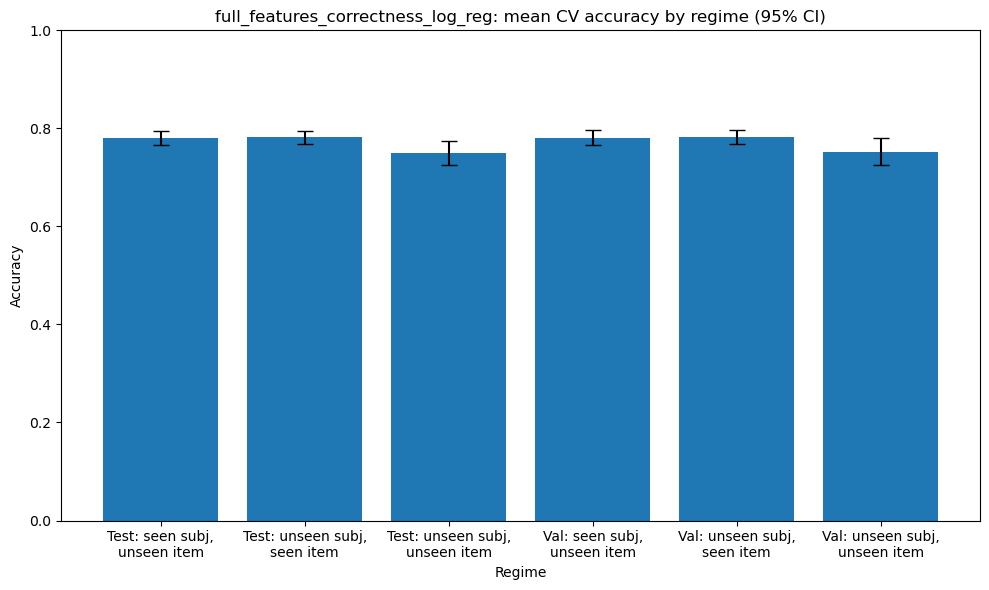

In [15]:
cv_regime_summary, fig, ax = plot_cv_accuracy_by_regime_pretty(cv_out)
display(cv_regime_summary)